# Real Estate Economics & Finance

## Supplemental Material

In [1]:
%pylab inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# mport pandas_datareader.data as web
# import datetime as dt
# import fix_yahoo_finance
import datetime
import yfinance as yf
import seaborn as sns
import statsmodels as sm
import statsmodels.formula.api as smf
import statsmodels.api as sma
import patsy
from statsmodels.graphics.api import abline_plot
import numpy.linalg as linalg
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap
from sklearn import neighbors, datasets
from tabulate import tabulate
sns.set(context='notebook', style='whitegrid', palette='deep', font='sans-serif', font_scale=1, rc=None)
from IPython.display import Image
import urllib.request as url
import io
import datetime as dt
from fredapi import Fred
fred = Fred(api_key='30e6ecb242a73869e11cb35f6aa3afc3')

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


## What Is the Difference Between Economics and Finance and How are they Used in Real Estate?
* At its core, economics studies **decision-making** in the face of **budget constraints** and **uncertainty**.
    * What are **budget constraints**?
    * What is **uncertainty**?



* **Finance** is a branch of economics.
    * Finance addresses ideas in **portfolio optimization**.  
    * A **portfolio** is a collection of assets whose returns are potentially correlated (either positively or negatively).  
    * In an idealized world, the holder of a portfolio can **buy** or **sell** assets to adjust the portfolio in very small increments **without fees or taxes** and without affecting asset **prices**.
    * As we will see, decisions are driven by the correlation patterns in returns and is called **diversification**.



* **Real Estate** is a particular asset class.
    * The ideas can be applied to CRE, but the underlying market **microstructure** is different.  **Location, location, location** or **brick-by-brick and block-by-block**.  I like to say either L$^3$ or b$\cdot 6$.

## Economics
* Demand for goods
* Supply of goods 
* Equilibrium price, p*, where Demand = Supply
* Comparative dynamics

## Finance 
* Demand for Investment in Assets
* Supply of Assets
* Equilibrium interest rate, i*, where Demand = Supply
* Comparative dynamics

## Real Estate
* Demand for space
* Supply of space
* Equilibrium rent, r*, where Demand = Supply
* Comparative dynamics

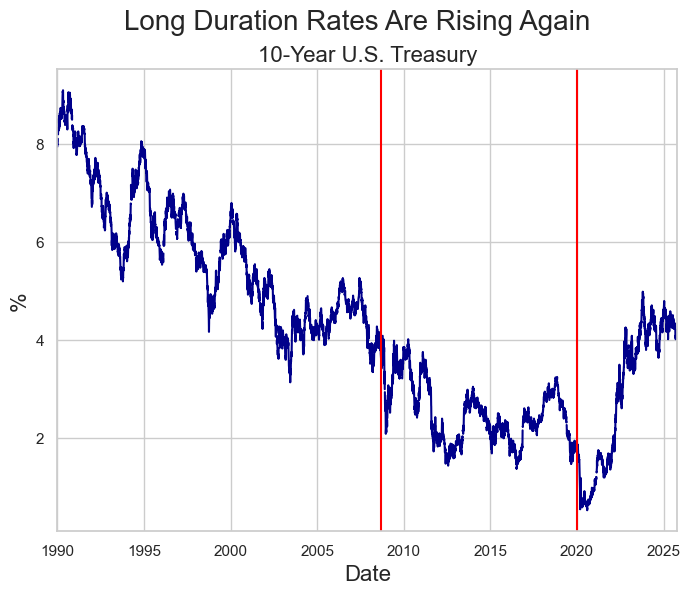

In [2]:
ten_year = fred.get_series("DGS10", observation_start='1990-01-01')
one_year = fred.get_series("DGS1", observation_start='1990-01-01')
three_month = fred.get_series("DGS3MO", observation_start='1990-01-01')

ten_year.plot(color='darkblue', figsize=(8, 6))
plt.suptitle('Long Duration Rates Are Rising Again', fontsize=20)
plt.title('10-Year U.S. Treasury', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.ylabel('%', fontsize=16)
plt.axvline(dt.datetime(2008, 9, 15), color="red")
plt.axvline(dt.datetime(2020, 1, 1), color="red")

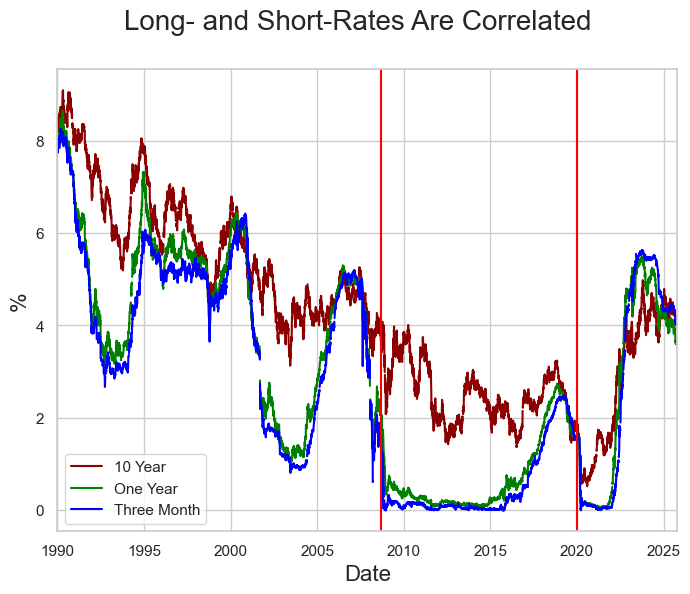

In [3]:
ten_year.plot(c='darkred', label='10 Year', figsize=(8, 6), )
one_year.plot(c='green', label='One Year')
three_month.plot(color='blue', label='Three Month')
plt.suptitle('Long- and Short-Rates Are Correlated', fontsize=20)
plt.legend()
plt.xlabel('Date', fontsize=16)
plt.ylabel('%', fontsize=16)
plt.axvline(dt.datetime(2008, 9, 15), color="red")
plt.axvline(dt.datetime(2020, 1, 1), color="red")

## Finance and Its Functions
* A branch of economics that studies financial markets.



* Prices are interest rates or equity prices.
    * Focus is on yields or returns.



* Demand is the demand for capital to deploy to its *highest and best use*, faced with risk and uncertainty.



* At its core, its function to match time preferences of the supply of capital (savers) and the demand for capital (investors).
    * Many intermediaries: Banks.
    * Banks borrow short and lend long.
    * Banks borrow liquid and lend illiquid.
        * A major source of risk is **simply time**.

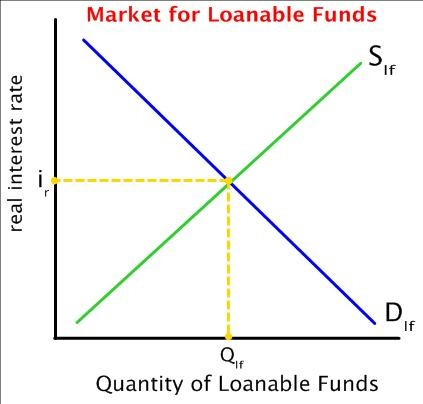

In [4]:
#from IPython.display import Image
url = 'https://sbhshgovapmacro.files.wordpress.com/2011/04/loanable-funds-graph.jpg'
Image(url, width=400, height=400)

## Important Market Distinctions
* Commodity markets (agriculture)



* Equity markets (stocks)



* Debt markets (bonds)



* Space markets (commercial real estate)
    * Traditional asset types: office, industrial, retail and multifamily.
    * Owners/landlords are supply. 
    * Tenants are demand.
    * Brokers are market makers. 
        * Traditional ten-year leases and relationship management.
    * Capital markets are **largely undifferentiated** flows of capital (absent, say, of government controls).
    * Real estate markets are **highly differentiated**, constituted of long-lived assets.
        * Total returns on the asset are rents (income) plus price appreciation (yield).
        * Income is driven by **local** conditions.
        * Yield is driven by **global** conditions.
    * Investor interest in real estate lies in the potential of **uncorrelated returns** (relative to a benchmark).
    * Space markets are, however, highly susceptible to **technological disruption**.
        * E-commerce and industrial/retail/multifamily.
        * Co-working and office.
        * Sharing economy and multifamily.
        * Emergence of niche real estate offerings, such as assisted living, self storage and student housing.

## Physical Demand for Real Estate
* Contrast with investor demand for real estate.



* Physical demand is driven largely by employment growth in the short run.
    * **Torto** and **Wheaton** have shown that near-term performance in rents and vacancy is driven by employment growth.

## Physical Supply of Real Estate
* Physics creates a kinked supply curve. 
    * Time from blueprint to construction to pre-leasing to lease up.
    * Space tends to be added rather than deducted from the physical stock.



* Employment growth has no impact on supply **until it does**.
    * Long Run Marginal Cost Curve (LRMC), an approximation to a supply curve.
        * Baseline: rent sufficient to maintain stock $\Rightarrow$ flat LRMC.
        * Rising: a unit of space becomes **ever more** costly due, for example, to physical constraints (land) or regulation (zoning).
        * Falling: less costly to build due to technological improvement (exogenous) or declining demand for a location (endogenous).  
            * Contrast Midtown with Hudson Yards.

## Capital Markets
* Core ideas of capital markets laid out by Walter Bagehot in *Lombard Street*.
    * Borrowing liquid and lending illiquid.
    * Borrowing short and lending long.
    * Essentially, a conversion of time and risk preferences.
    * Presented the notion of the lender of last resort, a role played by the Bank of England (at the time).
        * Lend freely, but at a high rate of interest to organizations or individuals with "good banking securities" (good collateral).




## Capital Markets for CRE
* In CRE, capital markets are global.
    * They may be informationally inefficient when compared with **public** bond and equity markets.



* But real estate remains a physical, local and largely immovable asset.



* The purpose of capital markets is to clear capital so that it is put to its **highest and best use**.



* Many risks associated with borrowing and lending:
    * Construction of real estate remains localized (and differentiated) while capital is global (and undifferentiated).

# The Time Value of Money (TVM) and the Principle of Discounting

## The Origin and Principle of Risk Aversion

1. **Certainty** is preferred to **uncertainty** (even if the expected payout is the same).
2. Consider a payout of 50 **with certainty** over the gamble of a coin flip.  I win 0 if the coin lands heads and 100 if the coin lands tails.  Given a **fair** coin, the expected outcome is 50.  
3. The same is true about consumption today versus consumption tomorrow.  **Tomorrow may not occur**.
4. The economics **drives** the mathematics of the time value of money.
5. The future is discounted because **it may never occur**.

## Present Value and Future Value

### Standard Equations
* Discounting: $PV = \displaystyle\frac{FV}{1+r}$
    * This basic idea is the foundation of much of the material we will cover.  
    * DCF, IRR, OCC and other measures common in the industry.


* Augmenting: $FV = (1+r)\cdot PV$

### Simple versus Compounding where N is the number of time periods


$ (1+r)^N \ge (N*r + 1) $ 

$ \forall r>0 $

$ N = 1: $

$ (1+r)^1 = (1+r) \ge 1*r + 1 = 1 + r $

$ N = 2: $

$ (1 + r)^2 \ge 2*r + 1 $

### The acronym PMT is typically used when considering the discounting of cash flows.  


* It the payment earned in one time period.
    * For equities, this would be a quarterly dividend payment.
    * For real estate, this would be the monthly rent paid by tenants (renters) to landlords (owners).


### How do we operationalize the idea of discounting?

* We use the discounting formula shown above: $PV = \displaystyle\frac{FV}{1+r}$ 



* $DCF = \displaystyle\frac{PMT}{1+r}$ are said to be the discounted cash flows that occur in the future.
    * Note the **inverse relationship** between the value of the DCF and the value of r.  As r rises, DCF must fall, holding constant the PMT.



* **Example**: 10,000 received in two years and 12,000 received in three years discounted by 10% and 11% respectively.



* $DCF=\frac{10000}{1.10^2}+\frac{12000}{1.11^3}=17038.76$ while undiscounted this value is $10000 + 12000 = 22000$.
    * Discounting **impares** the value of the sum.
    


* **Class Discussion**: 
    * What would happen to the value of the DCF if a higher discount rate, r, were used?
    * Why might we discount the PMT in period three by more than we discount the PMT in period two?  
    * What is r **meant to capture**?  How is calculated?

### Concepts
* **Annuity**: limited life of constant cash flow, such as rents on a 10-year lease.
* **Perpetuity**: infinitely lived cash flows, such UK gilts.  See [this](https://en.wikipedia.org/wiki/Gilt-edged_securities).

### A Simple Proof on the Convergence of Sums 
$S=a \cdot d^0 + a \cdot d^1 + a \cdot d^2 + ... + a \cdot d^{N-1}$ because $d^0 = 1$ for any real $d$



$S \cdot d = a \cdot d^1 + a \cdot d^2 + a \cdot d^3 + ... + a \cdot d^{N}$



* Subtract $S \cdot d$ from $S$ and virtually all terms cancel (standard math trick):



$S-S \cdot d = a-a \cdot d^N = a \cdot (1-d^N)$



* Note that $S-S \cdot d = S \cdot (1-d)$



* Equating the above:
$S \cdot (1-d) = a \cdot (1-d^N) \Rightarrow S = a \cdot \displaystyle \frac{1-d^N}{1-d}$, **which is finite**.



* $d$ is called the common factor.



* Because $d<1$, $\lim_{N \rightarrow \infty}S=a \cdot \displaystyle \frac{1}{1-d}$  
    * This proof is thousands of years old.



* Therefore, an **infinite sum of rents** is actually **finite**.  
    * Hence, it is possible to value a perpetuity because the infinite sum is finite.

### Example: DCF



* Suppose 240 payments remain on a monthly mortgage with 1,000 payments per month.



* What is the present of the mortgage today, which is the DCF?



* $PV=DCF=\frac{1000}{1.01^1}+\frac{1000}{1.01^2}+\frac{1000}{1.01^3}+...+\frac{1000}{1.01^{240}}$



* In this set up, 
    * $a=\frac{1000}{1.01}$ and $N=240$ and $d=1.01$
    * $PV = a \cdot \displaystyle \frac{1-d^N}{1-d} = 90819$
    * Undiscounted, this value is $1000*240=240000$
    * **This a profound point: the future is uncertain.  PMTs in the far future are increasingly uncertain and must be discounted heavily**.

### Example: PMT grows at a constant rate of g.



* That is, there is an escalation clause of 2% growth per annum and the lease is quoted in dollars/sqft starting at 20.  



* What is the PV (or DCF) of a 10-year lease?



* $PV=20\cdot\frac{1.02^0}{1.10^1}+20\cdot\frac{1.02^1}{1.10^2}+20\cdot\frac{1.02^2}{1.10^3}+...+20\cdot\frac{1.02^9}{1.10^{10}}$



* In this set up, 
    * $a=\frac{20}{1.10}$, $N=10$ and $d= \frac{1.02}{1.10}$
    * $PV = a \cdot \displaystyle \frac{1-d^N}{1-d} = 132.51$ per sqft
    
    
    
* More generally, the following formula can be derived: $PV=PMT_1 \cdot \big[\frac{1-(\frac{1+g}{1+r})^N}{r-g} \big]$ assuming $r\gt g$
    * If $g=0$, the old formula obtains.
    * This is called the **Gordon Growth Model**.

### Example: Consider a Perpetuity with Constant Growth

* 100 units with rent of 1,000 per month and operating expenses of 500.



* Assume at 5% vacancy (or 95% occupancy)



* Rents and expenses grow at the same 3% rate per year or 0.25% per month.  3/12 = 0.25.



* Opportunity cost of capital (OCC) is 12% per year or 1% per month.  12/12 = 1.



* What is the PV?
    * $PV=\frac{CF_1}{r-g}$ or $\frac{NOI}{r-g}$ assuming $r>g$
    * Cash flow is NOI $\cdot$ Units $\cdot$ Occupancy = (1000 - 500) $\cdot$ 100 $\cdot$ 0.95 = 47500
    * $PV = \frac{47500}{1.01} + \frac{1.0025 \cdot 47500}{1.01^2} + ... $



* In this example: 
    * $a=\frac{47500}{1.01}$ and $d= \frac{1.0025}{1.01}$
    * $PV = a \cdot \displaystyle \frac{1}{1-d} = 6333333$

### Summary
* $d=\displaystyle \frac{1}{1+r}$: annuity with no growth


* $d=\displaystyle \frac{1+g}{1+r}$: annuity with growth rate g


* $a=\displaystyle \frac{CF}{1+r}$: end of period


* $a=CF$: beginning of period


* Annuity: $N =$ number of periods


* Perpetuity: $N=\infty \Rightarrow d^N = 0$

### Discounted Cash Flows (DCF) and Intenal Rates of Return (IRR)
* DCF: Present value of a future stream of PMT.  This include monthly rents, as well as the value of a sale of the building, FV, at some future date, N.  The sale is called a **disposition**.



* $PV = \frac{PMT}{(1+r)^1} + \frac{PMT}{(1+r)^2} + ... + \frac{PMT}{(1+r)^N} + \frac{FV}{(1+r)^N} =$ Stream + Lump Sum


    * What share of PV is comprised of the stream and of the lump sum? 



* If cash flows are not well described by equal payments of a level annuity plus a lump sum, consider the use of an IRR (or hurdle rate).



* NPV $=\frac{CF_0}{(1+IRR)^0} + \frac{CF_1}{(1+IRR)^1} + \frac{CF_2}{(1+IRR)^2} + ... + \frac{CF_T}{(1+IRR)^T}$ when cash flows differ.  Note the basic structure of the sum of discounting a future stream.



* To solve for IRR, set NPV to zero.  The IRR is the rate that makes it **exactly zero**.



* If one could borrow at a rate below the IRR, this would be a positive NPV project and would be profitable.  If one could borrow only at a rate above the IRR, this would be a negative NPV project and would not be profitable.
    * This how monetary policy impacts the real economy, as we will study later in the semester.  
    * See the interest rate graph above.  

### Measuring Returns: Returns Are Performance
* Returns = (What you get when you sell - What it cost to buy) / (What it cost to buy).



* Ex post: Looking back using empirical data, such as observed cap rates.



* Ex ante: Looking forward using expectations, often using the statistical concept of an average.

### Total Returns
* $r_t = \displaystyle \frac{CF_t + V_t - V_{t-1}}{V_{t-1}}$



* $CF_t$: cash flow.  If CRE, monthly rent.  If a stock, a quarterly dividend.



* $V_t$: value today.  If CRE, property value.  If a stock, the current stock price.



* $V_{t-1}$: value in prior time period (yesterday, last month, last quarter, or last year).



* $r_t = \displaystyle \frac{CF_t}{V_{t-1}} + \big(\frac{V_t}{V_{t-1}} - 1\big) = y_t + g_t =$ current yield (or income) plus capital return (or growth).



* In CRE, current yield is monthly rent as a share of value and capital return is change in value.



* Therefore, total returns can **always** be decomposed into a **current yield** and **capital return**.
    * A bond has only a yield, making it sensitive to unexpected inflation: primary U.S. Treasury market.
    * A pure-growth stock has only a capital return, making it sensitive to expected growth: AMZN.

### Returns and Risk

* Risk aversion: 
    * **Certainty** is always preferred to a **gamble** (or coin flip) even with the same expected outcome.
        * A payout of 50 with **certainty** is prefered to a payout of either 0 or 100 from a random coin flip.
    * As a result, **investors must be compensated to bear risk**.  



* $E[r_t]=r_{f,t} + E[RP_t]$ $\Leftarrow$ Capital Asset Pricing Model (CAPM) that you will study in portfolio theory.



* Relations:
    * $r=y+g$
    * $r=r_f+RP$
    
    
    
* Basic measures:
    * Sharpe Ratio: $\displaystyle{\frac{\mu}{\sigma}}$, where $\mu$ is *ex ante* return and $\sigma$ is *ex post* risk.  ***IT measures risk-adjusted retrurns**.
    * It measures return for a unit of risk $\Rightarrow$ higher is better.

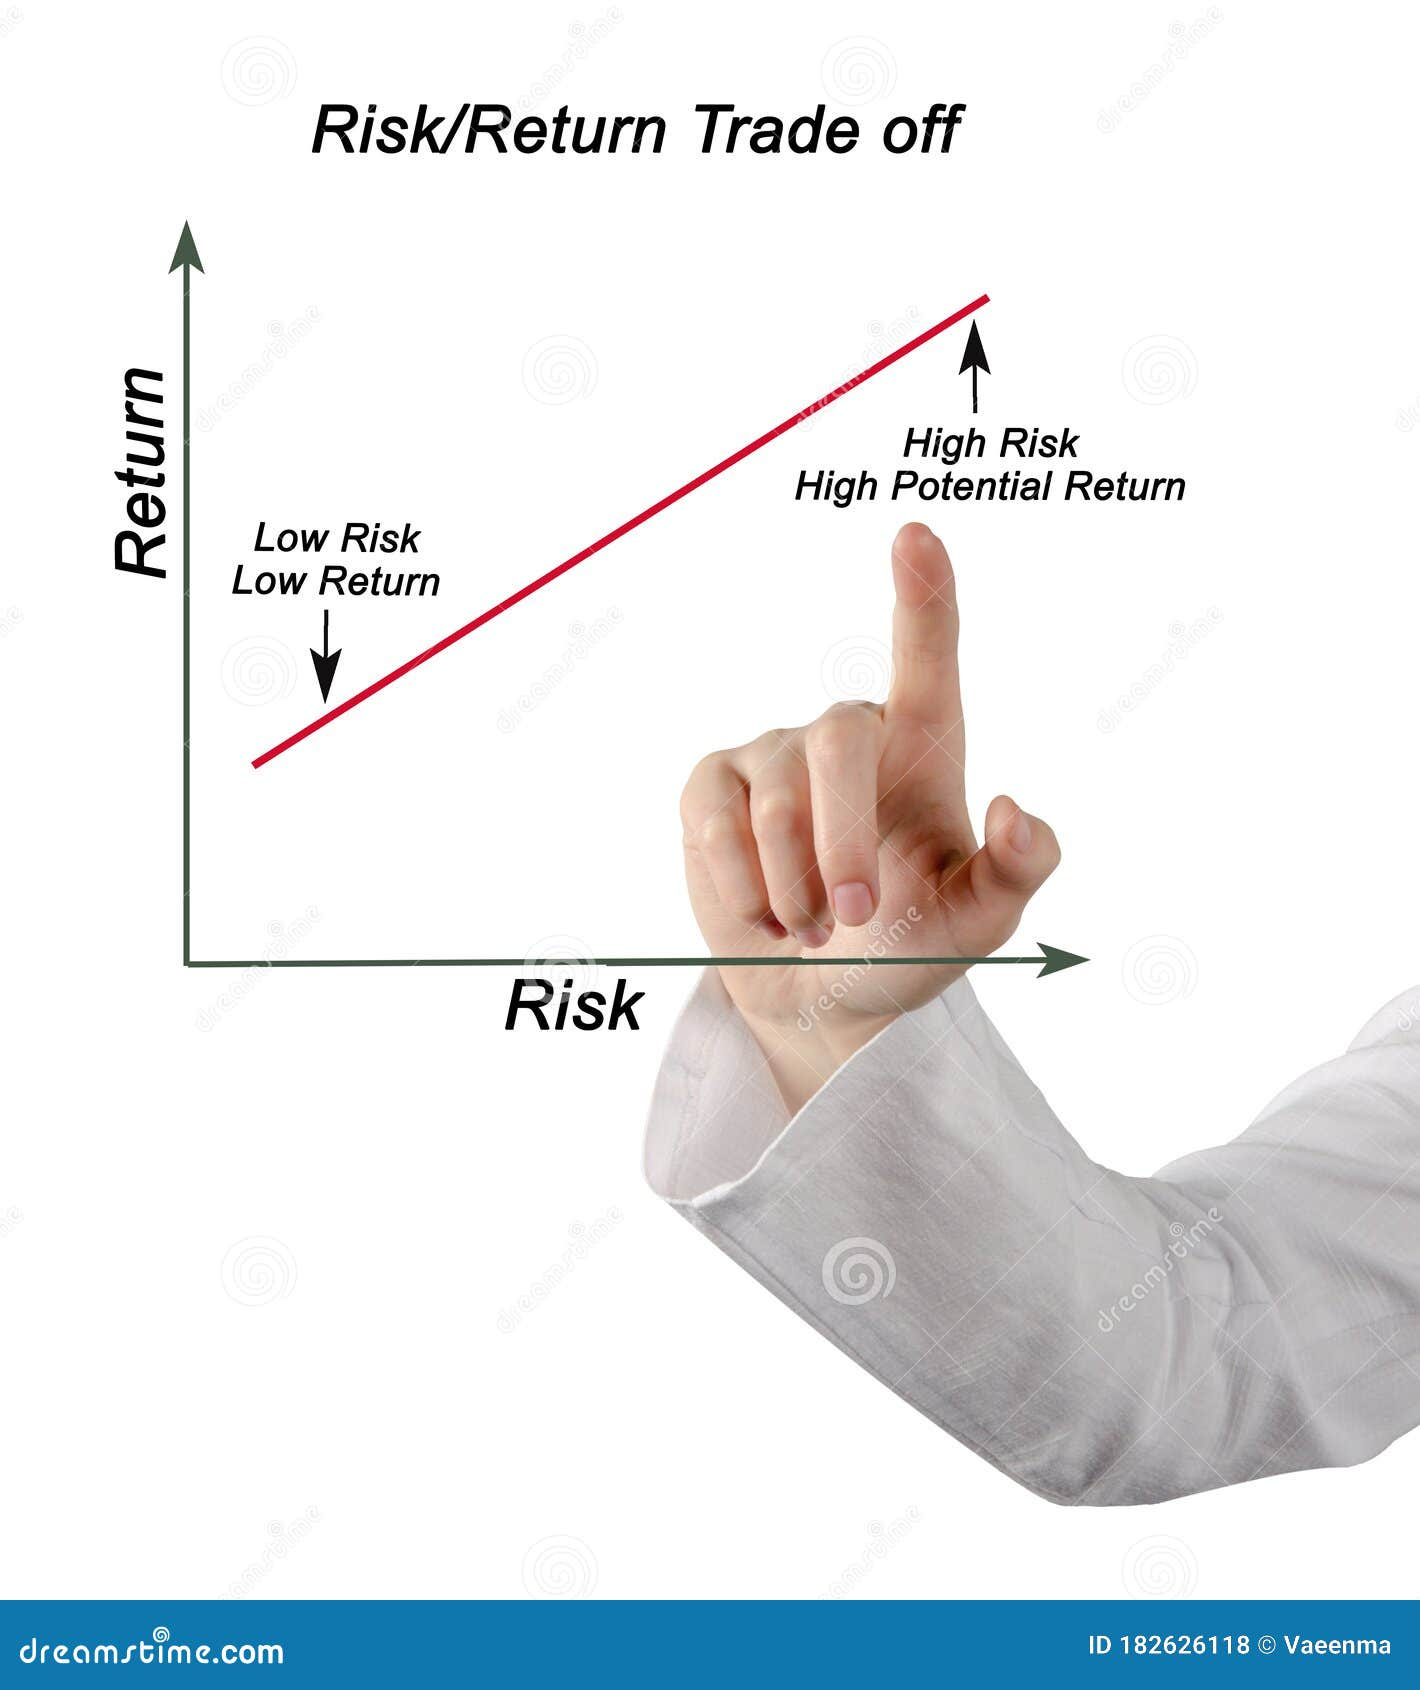

In [5]:
url = 'https://thumbs.dreamstime.com/z/graph-risk-return-trade-off-182626118.jpg'
Image(url, width=400, height=400)

### Introduction to Bond Pricing



* Recall, $PV = \displaystyle\frac{FV}{1+r}$



* This is how bonds (the oldest type of financial instrument) are priced in equilibrium.



* Again, note the **inverse relationship** between PV and r.  As r rises, PV must fall.  


* This is true for bonding pricing.  
    * In this case, PV is the price of the bond, while r is the yield on the bond.  
    * As bond yields rise, bond prices fall.   

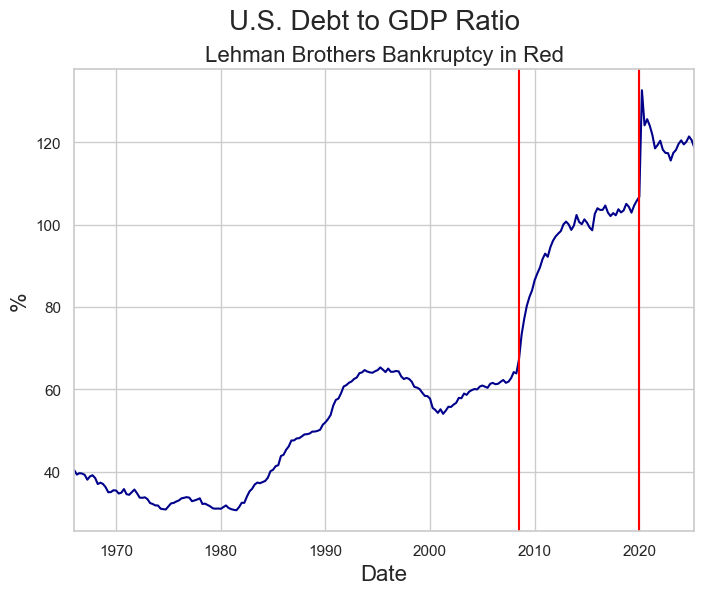

In [6]:
debt = fred.get_series("GFDEGDQ188S")
debt.plot(color='darkblue', figsize=(8, 6))
plt.suptitle('U.S. Debt to GDP Ratio', fontsize=20)
plt.title('Lehman Brothers Bankruptcy in Red', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.ylabel('%', fontsize=16)
plt.axvline(dt.datetime(2008, 9, 15), color="red")
plt.axvline(dt.datetime(2020, 2, 15), color="red")

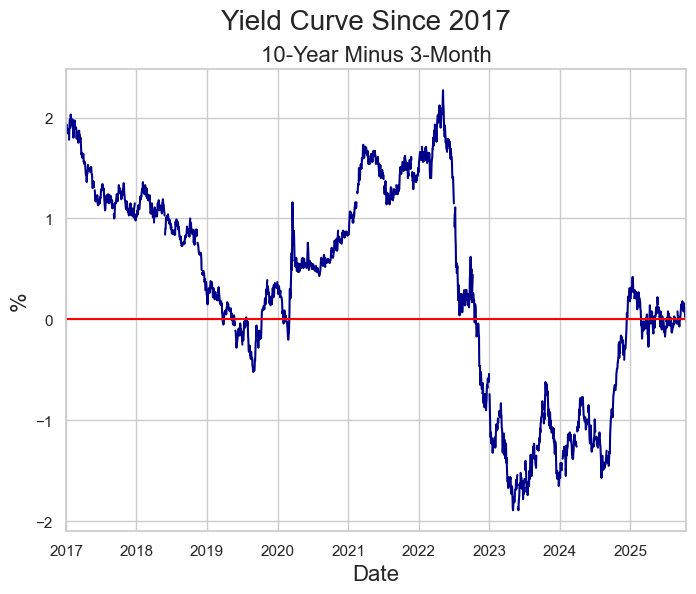

In [7]:
yield_curve = fred.get_series("T10Y3M", observation_start='2017-01-01')
yield_curve.plot(color='darkblue', figsize=(8, 6))
plt.suptitle('Yield Curve Since 2017', fontsize=20)
plt.title('10-Year Minus 3-Month', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.ylabel('%', fontsize=16)
plt.axhline(0, color="red")

# Monetary Policy and Central Banking

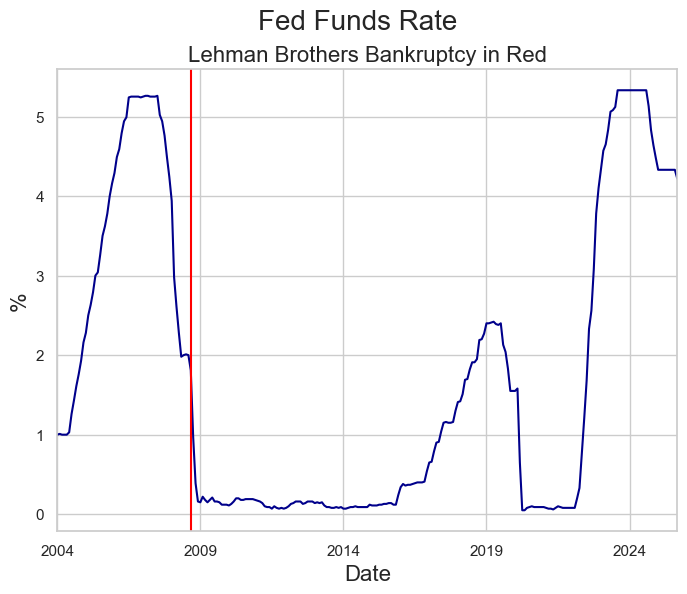

In [8]:
balance = fred.get_series("WALCL", observation_start='2004-01-01') / 1000000
fedfunds = fred.get_series("FEDFUNDS", observation_start='2004-01-01')
fedfunds.plot(color='darkblue', figsize=(8, 6))
plt.suptitle('Fed Funds Rate', fontsize=20)
plt.title('Lehman Brothers Bankruptcy in Red', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.ylabel('%', fontsize=16)
plt.axvline(dt.datetime(2008, 9, 15), color="red")

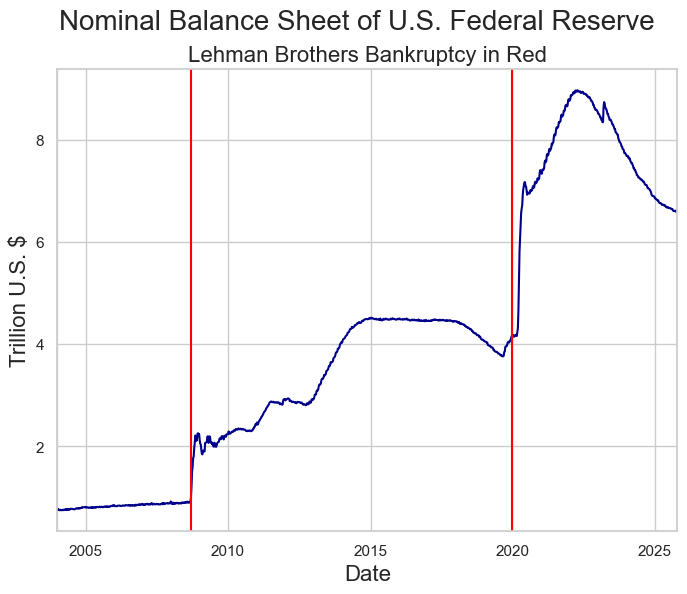

In [9]:
balance.plot(color='darkblue', figsize=(8, 6))
plt.suptitle('Nominal Balance Sheet of U.S. Federal Reserve', fontsize=20)
plt.title('Lehman Brothers Bankruptcy in Red', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.ylabel('Trillion U.S. $', fontsize=16)
plt.axvline(dt.datetime(2008, 9, 15), color="red")
plt.axvline(dt.datetime(2020, 1, 1), color="red")

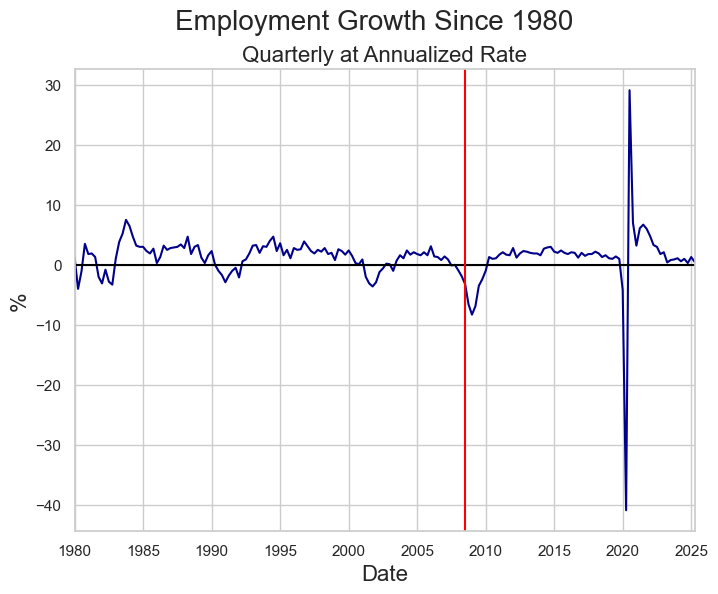

In [10]:
emp_growth = fred.get_series("PRS85006012", observation_start='1980-01-01')
emp_growth.plot(color='darkblue', figsize=(8, 6))
plt.suptitle('Employment Growth Since 1980', fontsize=20)
plt.title('Quarterly at Annualized Rate', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.ylabel('%', fontsize=16)
plt.axhline(0, color="black")
plt.axvline(dt.datetime(2008, 9, 15), color="red")

Text(0, 0.5, '%')

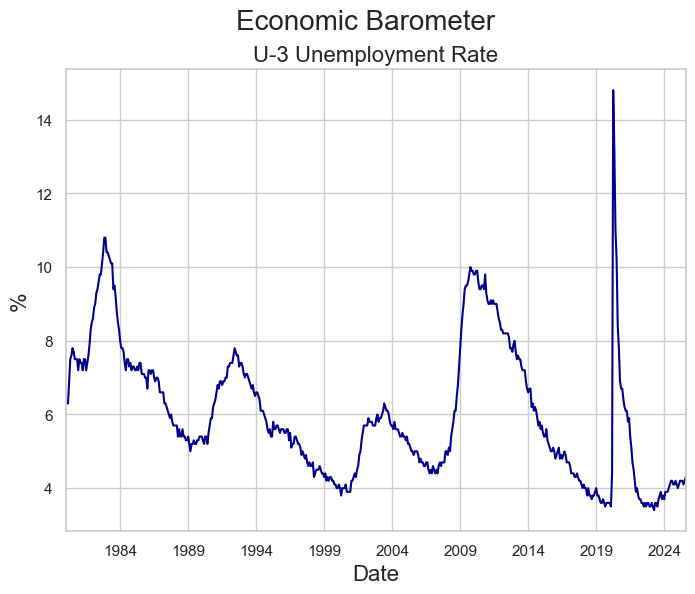

In [11]:
unemp_rate = fred.get_series("UNRATE", observation_start='1980-01-01')
unemp_rate.plot(color='darkblue', figsize=(8, 6))
plt.suptitle('Economic Barometer', fontsize=20)
plt.title('U-3 Unemployment Rate', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.ylabel('%', fontsize=16)

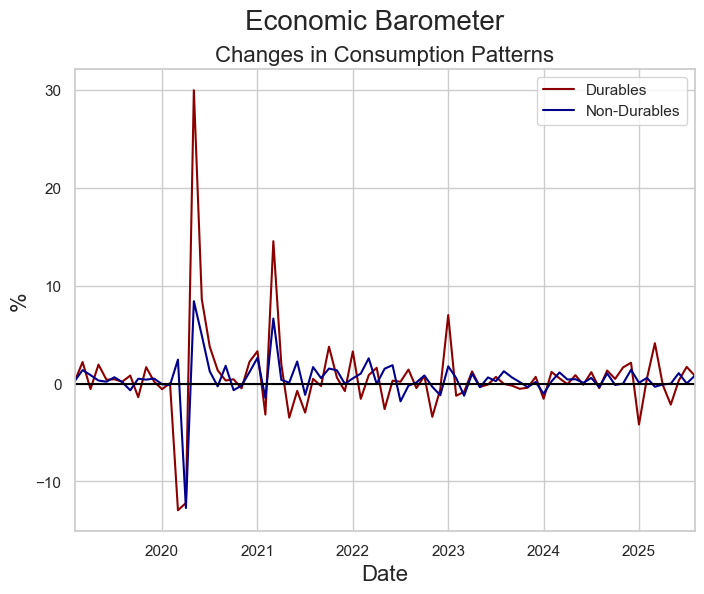

In [12]:
df = {}
df['Durables'] = fred.get_series("PCEDG", observation_start='2019-01-01').dropna()
df['Non-Durables'] = fred.get_series("PCEND", observation_start='2019-01-01').dropna()
df = pd.DataFrame(df)
df = df.pct_change(periods=1).dropna() * 100

colors = (["darkred", "darkblue"])
df.plot(figsize=(8, 6), color = colors)
plt.suptitle('Economic Barometer', fontsize=20)
plt.title('Changes in Consumption Patterns', fontsize=16)
plt.legend()
plt.xlabel('Date', fontsize=16)
plt.ylabel('%', fontsize=16)
plt.axhline(0, color='black')

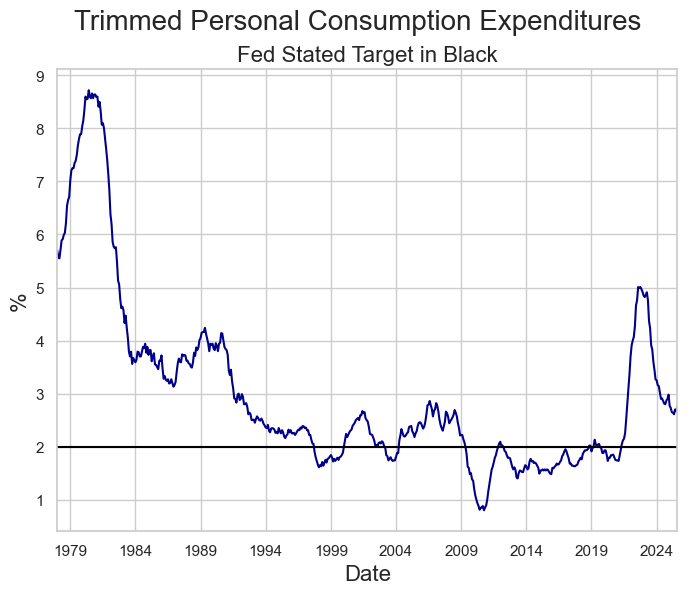

In [13]:
inflation = fred.get_series("PCETRIM12M159SFRBDAL")
inflation.plot(color='darkblue', figsize=(8, 6))
plt.suptitle('Trimmed Personal Consumption Expenditures', fontsize=20)
plt.title('Fed Stated Target in Black', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.ylabel('%', fontsize=16)
plt.axhline(2, color="black")

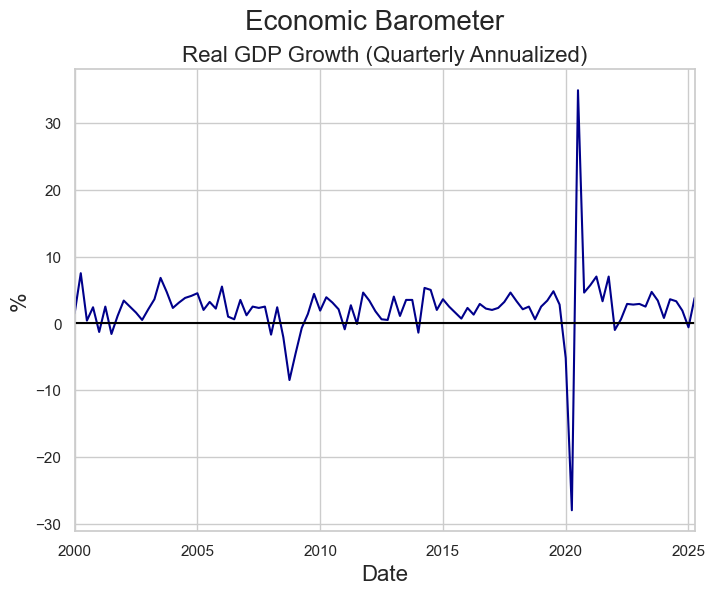

In [14]:
growth = fred.get_series("A191RL1Q225SBEA", observation_start='2000-01-01').dropna()
growth.plot(color='darkblue', figsize=(8, 6))
plt.suptitle('Economic Barometer', fontsize=20)
plt.title('Real GDP Growth (Quarterly Annualized)', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.ylabel('%', fontsize=16)
plt.axhline(0, color="black")

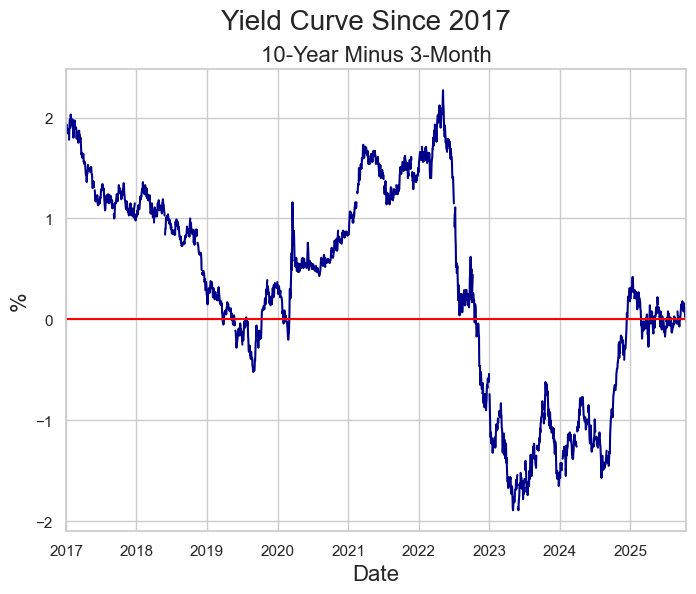

In [15]:
yield_curve = fred.get_series("T10Y3M", observation_start='2017-01-01')
yield_curve.plot(color='darkblue', figsize=(8, 6))
plt.suptitle('Yield Curve Since 2017', fontsize=20)
plt.title('10-Year Minus 3-Month', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.ylabel('%', fontsize=16)
plt.axhline(0, color="red")

Text(0.5, 0, 'Date')

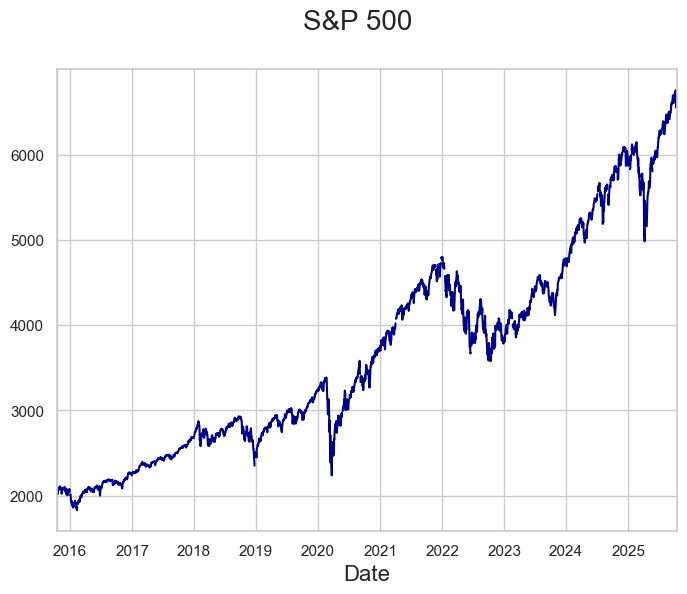

In [16]:
sp500 = fred.get_series("SP500")
sp500.plot(color='darkblue', figsize=(8, 6))
plt.suptitle('S&P 500', fontsize=20)
plt.xlabel('Date', fontsize=16)

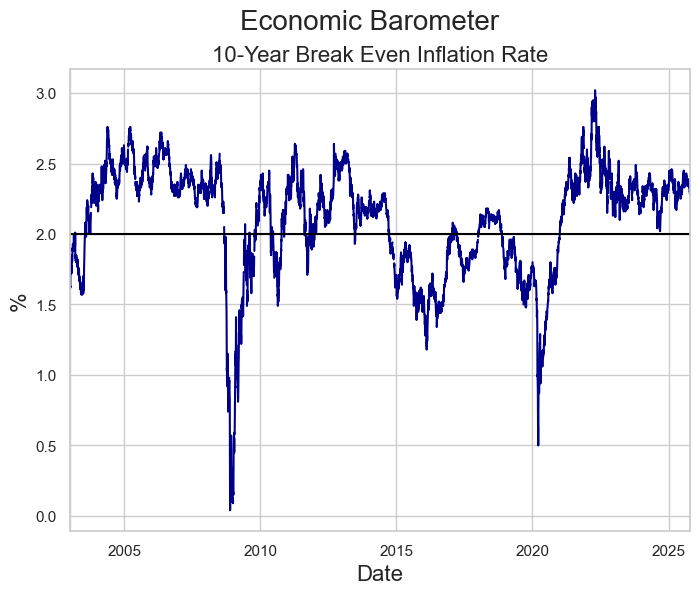

In [17]:
break_even = fred.get_series("T10YIE", observation_start='1990-01-01')
break_even.plot(color='darkblue', figsize=(8, 6))
plt.suptitle('Economic Barometer', fontsize=20)
plt.title('10-Year Break Even Inflation Rate', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.ylabel('%', fontsize=16)
plt.axhline(2, color="black")

Text(0, 0.5, '%')

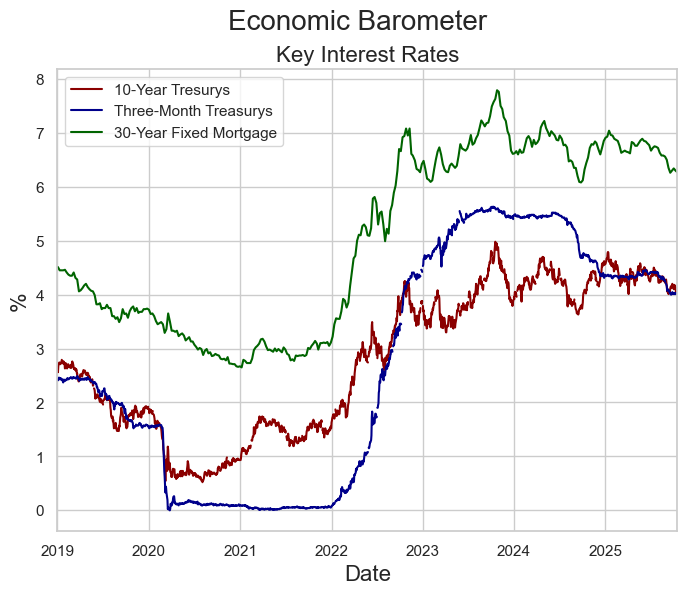

In [18]:
ten_year = fred.get_series("DGS10", observation_start='2019-01-01')
three_month = fred.get_series("DGS3MO", observation_start='2019-01-01')
ffr = fred.get_series("FEDFUNDS", observation_start='2019-01-01')
mortgage = fred.get_series("MORTGAGE30US", observation_start='2019-01-01')
yield_curve = fred.get_series("T10Y3M", observation_start='2019-01-01')

ten_year.plot(c='darkred', label='10-Year Tresurys', figsize=(8, 6), )
three_month.plot(color='darkblue', label='Three-Month Treasurys')
mortgage.plot(color='darkgreen', label='30-Year Fixed Mortgage')
plt.suptitle('Economic Barometer', fontsize=20)
plt.title('Key Interest Rates', fontsize=16)
plt.legend()
plt.xlabel('Date', fontsize=16)
plt.ylabel('%', fontsize=16)

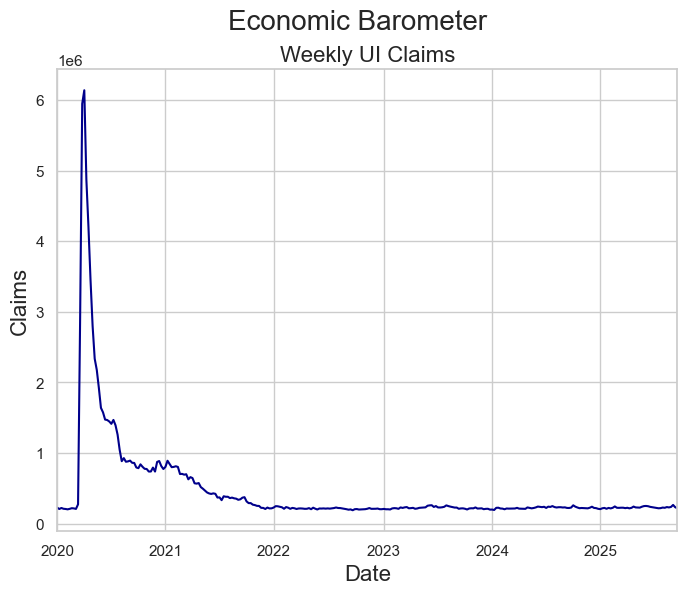

In [19]:
claims = fred.get_series("ICSA", observation_start='2020-01-01')
claims.plot(color='darkblue', figsize=(8, 6))
plt.suptitle('Economic Barometer', fontsize=20)
plt.title('Weekly UI Claims', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.ylabel('Claims', fontsize=16)
plt.axvline(dt.datetime(2008, 9, 15), color="red")

Text(0, 0.5, 'Thousands of Adults')

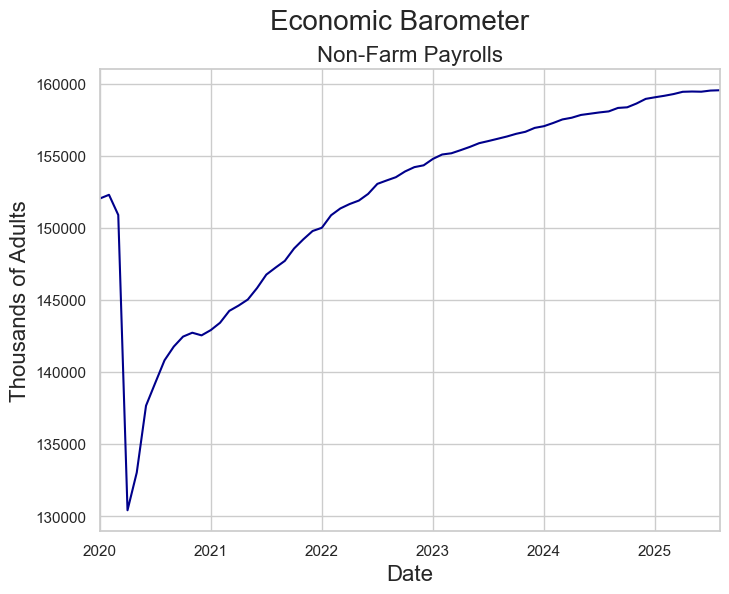

In [20]:
jobs = fred.get_series("PAYEMS", observation_start='2020-01-01')
jobs.plot(color='darkblue', figsize=(8, 6))
plt.suptitle('Economic Barometer', fontsize=20)
plt.title('Non-Farm Payrolls', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.ylabel('Thousands of Adults', fontsize=16)

## DCF and NPV

* What is an financial asset worth?  
    * Finacial assets have no intrinsic value.  **Their value is relative to available alternatives**.  (See [ketchup economics](https://www.investorschronicle.co.uk/2016/04/07/comment/in-praise-of-ketchup-economics-coZWQOc9NiittUVDTztU6J/article.html).)  
    * Their values are determined in a market by **supply and demand**.
    * The **method of DCF** is an *approach to valuation*.  **It is a model but not an algorithm**.
    * **Critical point**:  In real estate, cash flows may be independent of the price paid for an asset.
        * Why?  Cash flows are determined by supply and demand in a local market, as well as the prowess and ability of the owner/operator.  
        * Supply and demand in a market over time are largely independent of the price paid for a single asset in that market.   
        * Consider [Hudson Yards](https://www.hudsonyardsnewyork.com) in NYC.  Why might a developer and investor be interested in developing and owning an entire market like Hudson Yards?
        * Now consider the impact of **COVID**, which could not be forecast at the time decisions about Hudson Yards were made.  
    * As a result, prices paid **today** drive expected returns **in the future** that may not materialize.
        * An idea to consider: [the winner's curse](https://www.investopedia.com/terms/w/winnerscurse.asp).



* Example: 
    * NOI: 10,000
    * End of Period (EOP) Sale Price: 105,000
    * Purchase Price: 100,000
    * Return is (NOI + Change in Value) / Purchase Price
        * (10,000 + 5,000) / 100,000 = 15%



* Suppose instead you paid 105,000
    * (10,000 + 0) / 100,000 = 10%  
        * The book discounts, but I want to make this an easier example.

## The Inverse Relation Between Expected Returns and Values
* **Expected returns are inversely related to today’s prices**. 
    * Expected future cash flows (including resale) occur in the future, regardless of how much you pay today for the asset. 
    * They are determined by future economic factors that are independent of how much you pay today for the asset. 
    * **Future rents are determined by future supply and demand in the future**.  
    * Future resale prices are determined by future rents the next buyer expects after acquisition and that buyers’ IRR and their OCC at the time of resale. 
    * None of these factors is influenced by the price you pay today for the property.
    * Uncertainty and the risk-return trade-off.

## Discounted Cash Flow Valuation
* Standard valuation model is the discounted cash flow (DCF).
    * It is a model and **not an algorithm** and consists of three steps:



1. Forecast the expected future cash flows.
2. Ascertain the required total return.
3. Discount future cash flows to present value at the required total return.



* $V$ is present value based on its expected future performance:
$V = \displaystyle{\frac{E_0[CF_1]}{[1+E_0[r]]^1}+\frac{E_0[CF_2]}{[1+E_0[r]]^2}}+...+\frac{E_0[CF_{T-1}]}{[1+E_0[r]]^{T-1}}+\frac{E_0[CF_{T}]}{[1+E_0[r]]^{T}}$



* $CT_t$ are net cash flows (after expenses) in period t, which may be lumpy.



* $𝐸_0[r]$ is expected multi-period return as of time zero (today), which includes the OCC for the investment.



* $T$ is terminal period in the expected holding period, and $CF_T$ would include the net resale value of the property, as well as net cash flows in that period. 



* Value today is inversely related to expected future returns, $E_0[r]$  
    * Why?  
    * This does not sound intuitively correct **but it is**.



* Returns are percentage changes in a value, $\displaystyle{\frac{V_{t+1}-V_t}{V_t}=\frac{\Delta V}{V}}$



* Consider DW: more capital chasing a fixed stock of assets.
    * More demand, given a fixed stock, will increase values (or prices) today, $V_t$.
    * As a result, *ex ante* returns will decrease, absence changes in $V_{t+1}$, and future values are determined in the future.



* Consider loanable funds.
    * Given a fixed supply of capital, a decrease in demand decreases the real interest rate, which increases the number NPV positive projects.

## The Decomposition of Total Returns
* $r = r_f + RP$: total return is the sum of risk-free rate and risk premium.



* Long-term (10 years) leases with certain payments (monthly rent).  



* Consider this idea in the era of **COVID-19**.

## DCF is Direct Capitalization
* **Short cut**: 
    * $\displaystyle{\text{Value} = \frac{\text{NOI}}{\text{cap rate}} \Rightarrow \text{cap rate}=\frac{\text{NOI}}{\text{Value}}}$
    * Therefore, cap rates are yields: NOI as a share of value if a fully-leased property could be converted to cash immediately.
    * Consider **COVID**: it impacts both NOI and value, so it is not be surprising to see little change in cap rates, especially given **COVID** monetary policy.



* Gross income multiplier for small properties:
    * Given uncertainties in operating expenses.


* Uncertain cash flows must be discounted more heavily to reflect the uncertainty

# Real Estate Finance: Themes to Date
* Economics and finance drive the mathematics.



* Economics and finance allow us to think logically about how markets might perform.
    * Excel is tool.
    * Like death and taxes, it will always be with us.
    * But there are better and free tools available to do advanced modeling.
    * One might want to stress test a portfolio using Monte Carlo simulation.
    * One might want to backtest an investment strategy.
    * One might want to simulate potential performance using open sourced data.  (See Savage, Vo, and Zhao.)
    * The future lies with open source tools, such as R and Python.




### We discount the future because it may not occur.




### We recognize that there is a trade-off between *ex ante* return and risk, and *ex post* we may lose money.



### We are able to apply all of these themes to commercial real estate, as in Chapters 21 and 22.



### Capital is global, but real estate markets are local.



### Real estate markets have complex contracts that we call leases, governing the responsibilities of all parties (landlord, tenant and their representatives).



### Real estate assets are highly heterogeneous and illiquid.
#### They provide potential yield (cash flows) and growth (price appreciation) that may be uncorrelated with equities and bonds.



### An Introduction to Macroeconomics
* *Microeconomics*: the study of individual markets.
* *Macroeconomics*: the study of aggregate output, its fluctuations and their drivers.
* *Econometrics*: the use of statistical models to examine conjectures that arise from theory.



* We have touched on elements of each of these (and will continue to do so in your upcoming courses).
    * Microeconomics: DiPasquale-Wheaton
    * Macroeconomics: interest rate determination (via loanable funds market) and themes in finance
    * Econometrics (now data analytics more generally): modern portfolio theory and 3135
    * *I personally see no difference in any of these topics*
    
    

* The U.S. Federal Reserve was created by a 1913 Act following a large financial crisis and recession in 1907.  It is technically the banker's bank.  
    * Originally, it used the standard tool of the discount window to lend to banks under the gold standard of convertability.
    * In 1933, the gold standard was suspended.
    * During WWII, the Fed began explicit interest rate setting.
    * It was made operationally independent of the U.S. Treasury in the early 1950's under admendments to 1913 Act.
    * The role of the discount window substantially diminished, as did change the reserve ratio.  Primary focus was on OMOs.
    * **Not transparent**.  No explicit statements about overnight Fed Fund rate.  No forward guidance.  No regular testimony to Congress.
    * During the GFC, new tools were needed.  Transparency itself was seen as a tool.  

## A Brief Introduction to Markov Processes

* Markov processes are already familiar to anyone with a calendar.
* Everything I need to know about **tomorrow** is contained by my knowledge of **today**.
* Markov processes are a fundamental building block of time series.

In [21]:
print("The Calendar: A Deterministic Markov Transition Matrix")
table = [[" ", "S", "M", "T", "W", "T", "F", "S"],
         ["S", "0", "1", "0", "0", "0", "0", "0",],
         ["M", "0", "0", "1", "0", "0", "0", "0",],
         ["T", "0", "0", "0", "1", "0", "0", "0",],
         ["W", "0", "0", "0", "0", "1", "0", "0",],
         ["T", "0", "0", "0", "0", "0", "1", "0",],
         ["F", "0", "0", "0", "0", "0", "0", "1",],
         ["S", "1", "0", "0", "0", "0", "0", "0",],]
print(tabulate(table, tablefmt="fancy_grid", numalign = "center"))
print()

The Calendar: A Deterministic Markov Transition Matrix
╒═══╤═══╤═══╤═══╤═══╤═══╤═══╤═══╕
│   │ S │ M │ T │ W │ T │ F │ S │
├───┼───┼───┼───┼───┼───┼───┼───┤
│ S │ 0 │ 1 │ 0 │ 0 │ 0 │ 0 │ 0 │
├───┼───┼───┼───┼───┼───┼───┼───┤
│ M │ 0 │ 0 │ 1 │ 0 │ 0 │ 0 │ 0 │
├───┼───┼───┼───┼───┼───┼───┼───┤
│ T │ 0 │ 0 │ 0 │ 1 │ 0 │ 0 │ 0 │
├───┼───┼───┼───┼───┼───┼───┼───┤
│ W │ 0 │ 0 │ 0 │ 0 │ 1 │ 0 │ 0 │
├───┼───┼───┼───┼───┼───┼───┼───┤
│ T │ 0 │ 0 │ 0 │ 0 │ 0 │ 1 │ 0 │
├───┼───┼───┼───┼───┼───┼───┼───┤
│ F │ 0 │ 0 │ 0 │ 0 │ 0 │ 0 │ 1 │
├───┼───┼───┼───┼───┼───┼───┼───┤
│ S │ 1 │ 0 │ 0 │ 0 │ 0 │ 0 │ 0 │
╘═══╧═══╧═══╧═══╧═══╧═══╧═══╧═══╛



In [22]:
print("Day of Week Vector: Today is Monday")
table = [["S", "M", "T", "W", "T", "F", "S"],
         ["0", "1", "0", "0", "0", "0", "0",]]
print(tabulate(table, tablefmt="fancy_grid", numalign = "center"))
print()

Day of Week Vector: Today is Monday
╒═══╤═══╤═══╤═══╤═══╤═══╤═══╕
│ S │ M │ T │ W │ T │ F │ S │
├───┼───┼───┼───┼───┼───┼───┤
│ 0 │ 1 │ 0 │ 0 │ 0 │ 0 │ 0 │
╘═══╧═══╧═══╧═══╧═══╧═══╧═══╛



### How do we iterate the day of the week?  
* Today is Monday.  This is called the state of the system.



* What is tomorrow?  We want to iterate the system through time.



* day of week vector * Markov transition matrix = ?

In [23]:
# Let's find out.

MT = np.matrix('0 1 0 0 0 0 0; 0 0 1 0 0 0 0; 0 0 0 1 0 0 0; 0 0 0 0 1 0 0; 0 0 0 0 0 1 0; 0 0 0 0 0 0 1; 1 0 0 0 0 0 0')
dow = np.matrix('0 1 0 0 0 0 0')

print("Markov Transition Matrix")
print(MT)
print()
print("Today")
print(dow)
print()
print("Tomorrow")
print (dow * MT)
print()
print("The Day After Tomorrow")
print (dow * MT * MT)
print()
print("The Day After Tomorrow Using Linear Algebra")
print (dow * np.linalg.matrix_power(MT, 2))

Markov Transition Matrix
[[0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0]
 [0 0 0 1 0 0 0]
 [0 0 0 0 1 0 0]
 [0 0 0 0 0 1 0]
 [0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0]]

Today
[[0 1 0 0 0 0 0]]

Tomorrow
[[0 0 1 0 0 0 0]]

The Day After Tomorrow
[[0 0 0 1 0 0 0]]

The Day After Tomorrow Using Linear Algebra
[[0 0 0 1 0 0 0]]


### Why are these useful in finance?
* Burton Malkiel's *A Random Walk Down Wall Street*.



* Set an arbitrary starting point and iterate the system using a simple Markov process.



* Each second, this Markov process can move up 1 or it can move down, which it does at random.



* Pr(up) = Pr(down) = 0.5.

Text(0.5, 0, 'Seconds')

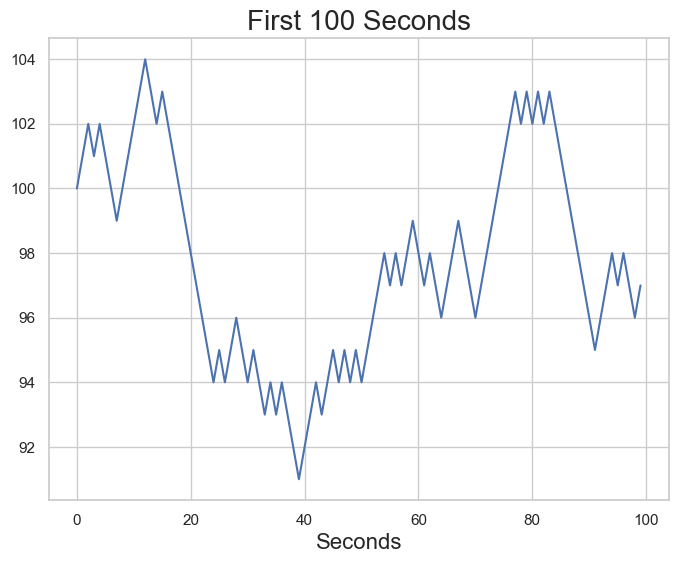

In [24]:
random.seed(1234)

pos = 100  
walk = [pos] 
nsteps = 10000 
for i in range(nsteps):
    step = 1 if np.random.randint(0, 2) else -1
    pos += step
    walk.append(pos)

plt.figure(figsize=(8, 6))
plt.plot(walk[0:100])
plt.title('First 100 Seconds', fontsize=20)
plt.xlabel('Seconds', fontsize=16)

Text(0.5, 0, 'Seconds')

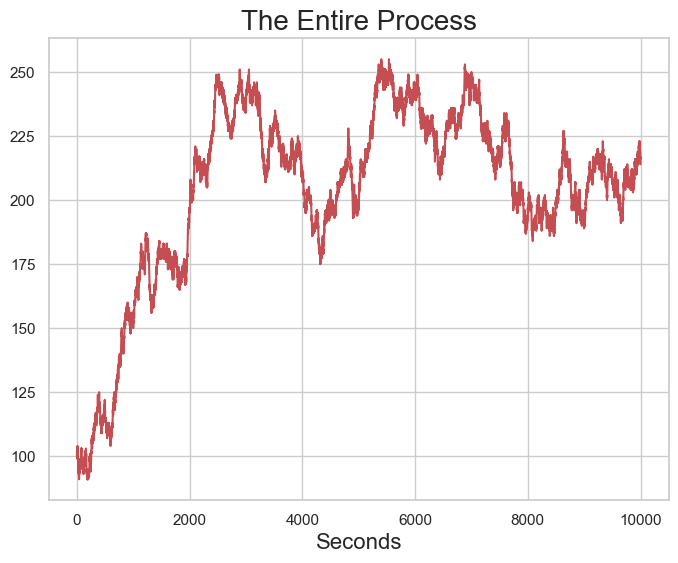

In [25]:
plt.figure(figsize=(8, 6))
plt.plot(walk, 'r')
plt.title("The Entire Process", fontsize=20)
plt.xlabel('Seconds', fontsize=16)

### What does this look like?

Text(0, 0.5, '$')

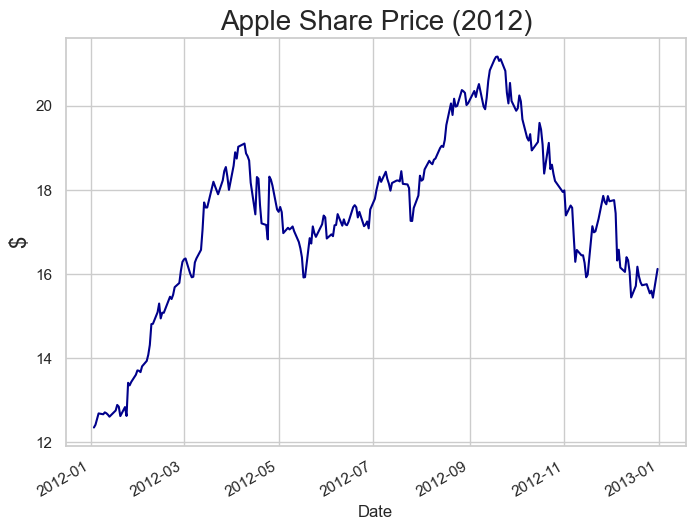

In [26]:
start_date = datetime.datetime(2012, 1, 1)
end_date = datetime.datetime(2013, 1, 1)
aapl = yf.Ticker("AAPL")
aapl = aapl.history(start=start_date, end=end_date)['Close']
aapl.plot(color = 'darkblue', figsize=(8, 6))
plt.title('Apple Share Price (2012)', fontsize=20)
plt.ylabel('$', fontsize=16)

## Examples
* Markowitz's other key insight: $E(r_i)-r_f = \alpha + \beta \cdot (E(r_{Mi})-r_f)$ is a statistical application:
    * $r_i = \alpha + \beta \cdot r_{Mi} + \epsilon_i$, where $\alpha$ is the intercept and $\beta$ is the slope.



* CAPM Notebook